# Pré-processamento de Dados - Sentiment140

Este notebook implementa o pré-processamento completo dos dados do dataset Sentiment140 para análise de sentimentos.

## Objetivos:
1. Carregar o dataset CSV
2. Aplicar limpeza de textos (remoção de URLs, menções, etc.)
3. Normalizar textos (lowercasing, remoção de pontuação)
4. Tokenizar e remover stopwords
5. Aplicar lematização
6. Salvar dados pré-processados


In [4]:
!pip install matplotlib


[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Importações e Configurações


In [5]:
# Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from pathlib import Path
import warnings
from tqdm import tqdm
import importlib.util

warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Importar funções de pré-processamento usando importlib (mesmo padrão dos outros scripts)
preprocessing_path = Path().resolve().parent / 'src' / '2_preprocessing.py'
spec = importlib.util.spec_from_file_location("preprocessing", str(preprocessing_path))
preprocessing_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(preprocessing_module)
clean_text = preprocessing_module.clean_text
clean_text_batch = preprocessing_module.clean_text_batch

print("✓ Bibliotecas importadas com sucesso!")


Baixando 'wordnet'...


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\eduar\AppData\Roaming\nltk_data...


Baixando 'omw-1.4'...


[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\eduar\AppData\Roaming\nltk_data...


✓ Bibliotecas importadas com sucesso!


## 2. Carregamento dos Dados


In [6]:
# Carregar o dataset processado
data_path = '../data/sentiment140_processed.csv'

print(f"Carregando dataset de: {data_path}")
df = pd.read_csv(data_path, encoding='utf-8', low_memory=False)

print(f"\n✓ Dataset carregado com sucesso!")
print(f"Shape: {df.shape}")
print(f"Colunas: {df.columns.tolist()}")
print(f"\nPrimeiras linhas:")
df.head()


Carregando dataset de: ../data/sentiment140_processed.csv

✓ Dataset carregado com sucesso!
Shape: (1600000, 2)
Colunas: ['text', 'label']

Primeiras linhas:


,text,label
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,is upset that he can't update his Facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,0
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",0


### 2.1 Informações do Dataset


In [7]:
# Informações gerais do dataset
print("Informações do Dataset:")
print(f"Total de linhas: {len(df):,}")
print(f"Total de colunas: {len(df.columns)}")
print(f"\nValores nulos:")
print(df.isnull().sum())
print(f"\nDistribuição de classes:")
print(df['label'].value_counts().sort_index())
print(f"\nTipos de dados:")
print(df.dtypes)


Informações do Dataset:
Total de linhas: 1,600,000
Total de colunas: 2

Valores nulos:
text     0
label    0
dtype: int64

Distribuição de classes:
label
0    800000
1    800000
Name: count, dtype: int64

Tipos de dados:
text     object
label     int64
dtype: object


## 3. Exemplos de Textos Antes do Pré-processamento


In [8]:
# Visualizar alguns exemplos de textos originais
print("="*80)
print("EXEMPLOS DE TEXTOS ORIGINAIS")
print("="*80)

# Exemplos de cada classe
examples_negative = df[df['label'] == 0]['text'].head(3)
examples_positive = df[df['label'] == 1]['text'].head(3)

print("\n📉 Textos NEGATIVOS (label=0):")
print("-" * 80)
for i, text in enumerate(examples_negative, 1):
    print(f"\n{i}. {text[:200]}{'...' if len(text) > 200 else ''}")

print("\n\n📈 Textos POSITIVOS (label=1):")
print("-" * 80)
for i, text in enumerate(examples_positive, 1):
    print(f"\n{i}. {text[:200]}{'...' if len(text) > 200 else ''}")


EXEMPLOS DE TEXTOS ORIGINAIS

📉 Textos NEGATIVOS (label=0):
--------------------------------------------------------------------------------

1. @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D

2. is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!

3. @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds


📈 Textos POSITIVOS (label=1):
--------------------------------------------------------------------------------

1. I LOVE @Health4UandPets u guys r the best!! 

2. im meeting up with one of my besties tonight! Cant wait!!  - GIRL TALK!!

3. @DaRealSunisaKim Thanks for the Twitter add, Sunisa! I got to meet you once at a HIN show here in the DC area and you were a sweetheart. 


## 4. Verificação e Download de Recursos NLTK


In [9]:
# Garantir que todos os recursos do NLTK necessários estejam disponíveis
import nltk

print("Verificando e baixando recursos do NLTK...")

# Lista de recursos necessários
resources = ['punkt', 'stopwords', 'wordnet', 'omw-1.4']

for resource in resources:
    try:
        if resource == 'punkt':
            nltk.data.find('tokenizers/punkt')
        elif resource == 'stopwords':
            nltk.data.find('corpora/stopwords')
        elif resource == 'wordnet':
            nltk.data.find('corpora/wordnet')
        elif resource == 'omw-1.4':
            nltk.data.find('corpora/omw-1.4')
        print(f"✓ {resource} já está disponível")
    except LookupError:
        print(f"⬇ Baixando {resource}...")
        if resource == 'punkt':
            nltk.download('punkt', quiet=True)
        elif resource == 'stopwords':
            nltk.download('stopwords', quiet=True)
        elif resource == 'wordnet':
            nltk.download('wordnet', quiet=True)
        elif resource == 'omw-1.4':
            nltk.download('omw-1.4', quiet=True)
        print(f"✓ {resource} baixado com sucesso")

print("\n✓ Todos os recursos do NLTK estão prontos!")


Verificando e baixando recursos do NLTK...
✓ punkt já está disponível
✓ stopwords já está disponível
⬇ Baixando wordnet...
✓ wordnet baixado com sucesso
⬇ Baixando omw-1.4...
✓ omw-1.4 baixado com sucesso

✓ Todos os recursos do NLTK estão prontos!


## 5. Teste da Função de Pré-processamento


In [10]:
# Testar a função de pré-processamento com alguns exemplos
print("="*80)
print("TESTE DA FUNÇÃO DE PRÉ-PROCESSAMENTO")
print("="*80)

# Selecionar alguns exemplos para teste
test_examples = df['text'].head(5).tolist()

print("\nComparação ANTES e DEPOIS do pré-processamento:\n")
for i, original_text in enumerate(test_examples, 1):
    try:
        cleaned_text = clean_text(original_text)

        print(f"{'='*80}")
        print(f"Exemplo {i}:")
        print(f"{'='*80}")
        print(f"ORIGINAL ({len(original_text)} caracteres):")
        print(f"  {original_text}")
        print(f"\nPRÉ-PROCESSADO ({len(cleaned_text)} caracteres):")
        print(f"  {cleaned_text}")
        print()
    except Exception as e:
        print(f"Erro ao processar exemplo {i}: {e}")
        print(f"Texto original: {original_text[:100]}...")


TESTE DA FUNÇÃO DE PRÉ-PROCESSAMENTO

Comparação ANTES e DEPOIS do pré-processamento:

Exemplo 1:
ORIGINAL (115 caracteres):
  @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D

PRÉ-PROCESSADO (50 caracteres):
  awww thats bummer shoulda got david carr third day

Exemplo 2:
ORIGINAL (111 caracteres):
  is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!

PRÉ-PROCESSADO (74 caracteres):
  upset cant update facebook texting might cry result school today also blah

Exemplo 3:
ORIGINAL (89 caracteres):
  @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds

PRÉ-PROCESSADO (47 caracteres):
  dived many time ball managed save rest go bound

Exemplo 4:
ORIGINAL (47 caracteres):
  my whole body feels itchy and like its on fire 

PRÉ-PROCESSADO (31 caracteres):
  whole body feel itchy like fire

Exemplo 5:
ORIGINAL (111 caracteres):
 

## 6. Estatísticas dos Textos Antes do Pré-processamento


In [11]:
# Calcular estatísticas dos textos originais
df['text_length_original'] = df['text'].str.len()
df['word_count_original'] = df['text'].str.split().str.len()

print("Estatísticas dos Textos ORIGINAIS:")
print("="*80)
print(f"\nComprimento (caracteres):")
print(df['text_length_original'].describe())
print(f"\nContagem de palavras:")
print(df['word_count_original'].describe())
print(f"\nEstatísticas por classe:")
print("\nNEGATIVOS (label=0):")
print(f"  - Média de caracteres: {df[df['label']==0]['text_length_original'].mean():.1f}")
print(f"  - Média de palavras: {df[df['label']==0]['word_count_original'].mean():.1f}")
print("\nPOSITIVOS (label=1):")
print(f"  - Média de caracteres: {df[df['label']==1]['text_length_original'].mean():.1f}")
print(f"  - Média de palavras: {df[df['label']==1]['word_count_original'].mean():.1f}")


Estatísticas dos Textos ORIGINAIS:

Comprimento (caracteres):
count    1.600000e+06
mean     7.409011e+01
std      3.644114e+01
min      6.000000e+00
25%      4.400000e+01
50%      6.900000e+01
75%      1.040000e+02
max      3.740000e+02
Name: text_length_original, dtype: float64

Contagem de palavras:
count    1.600000e+06
mean     1.317615e+01
std      6.957978e+00
min      1.000000e+00
25%      7.000000e+00
50%      1.200000e+01
75%      1.900000e+01
max      6.400000e+01
Name: word_count_original, dtype: float64

Estatísticas por classe:

NEGATIVOS (label=0):
  - Média de caracteres: 74.3
  - Média de palavras: 13.6

POSITIVOS (label=1):
  - Média de caracteres: 73.9
  - Média de palavras: 12.8


## 7. Aplicação do Pré-processamento em Todo o Dataset


In [12]:
# Aplicar pré-processamento em todos os textos
# NOTA: Para datasets grandes, isso pode levar algum tempo

print("="*80)
print("APLICANDO PRÉ-PROCESSAMENTO EM TODO O DATASET")
print("="*80)
print(f"\nTotal de textos para processar: {len(df):,}")
print("\n⏳ Iniciando pré-processamento (isso pode levar alguns minutos)...\n")

# Aplicar clean_text com barra de progresso
tqdm.pandas(desc="Pré-processando textos")
df['text_clean'] = df['text'].progress_apply(clean_text)

print("\n✓ Pré-processamento concluído!")


APLICANDO PRÉ-PROCESSAMENTO EM TODO O DATASET

Total de textos para processar: 1,600,000

⏳ Iniciando pré-processamento (isso pode levar alguns minutos)...



Pré-processando textos: 100%|██████████| 1600000/1600000 [02:12<00:00, 12070.14it/s]


✓ Pré-processamento concluído!


### 6.1 Remover Textos Vazios Após Pré-processamento


In [13]:
# Remover textos que ficaram vazios após o pré-processamento
original_size = len(df)
df = df[df['text_clean'].str.strip() != ''].copy()
removed = original_size - len(df)

print(f"Textos removidos (vazios após pré-processamento): {removed:,}")
print(f"Percentual removido: {(removed/original_size*100):.2f}%")
print(f"Shape final: {df.shape}")
print(f"Distribuição de classes após remoção:")
print(df['label'].value_counts().sort_index())


Textos removidos (vazios após pré-processamento): 8,131
Percentual removido: 0.51%
Shape final: (1591869, 5)
Distribuição de classes após remoção:
label
0    796269
1    795600
Name: count, dtype: int64


## 7. Estatísticas dos Textos Após Pré-processamento


In [14]:
# Calcular estatísticas dos textos pré-processados
df['text_length_clean'] = df['text_clean'].str.len()
df['word_count_clean'] = df['text_clean'].str.split().str.len()

print("Estatísticas dos Textos PRÉ-PROCESSADOS:")
print("="*80)
print(f"\nComprimento (caracteres):")
print(df['text_length_clean'].describe())
print(f"\nContagem de palavras:")
print(df['word_count_clean'].describe())
print(f"\nEstatísticas por classe:")
print("\nNEGATIVOS (label=0):")
print(f"  - Média de caracteres: {df[df['label']==0]['text_length_clean'].mean():.1f}")
print(f"  - Média de palavras: {df[df['label']==0]['word_count_clean'].mean():.1f}")
print("\nPOSITIVOS (label=1):")
print(f"  - Média de caracteres: {df[df['label']==1]['text_length_clean'].mean():.1f}")
print(f"  - Média de palavras: {df[df['label']==1]['word_count_clean'].mean():.1f}")


Estatísticas dos Textos PRÉ-PROCESSADOS:

Comprimento (caracteres):
count    1.591869e+06
mean     4.224927e+01
std      2.368276e+01
min      1.000000e+00
25%      2.300000e+01
50%      3.900000e+01
75%      5.900000e+01
max      1.730000e+02
Name: text_length_clean, dtype: float64

Contagem de palavras:
count    1.591869e+06
mean     7.113657e+00
std      3.875084e+00
min      1.000000e+00
25%      4.000000e+00
50%      7.000000e+00
75%      1.000000e+01
max      3.500000e+01
Name: word_count_clean, dtype: float64

Estatísticas por classe:

NEGATIVOS (label=0):
  - Média de caracteres: 43.2
  - Média de palavras: 7.3

POSITIVOS (label=1):
  - Média de caracteres: 41.3
  - Média de palavras: 6.9


## 8. Comparação Visual: Antes vs. Depois


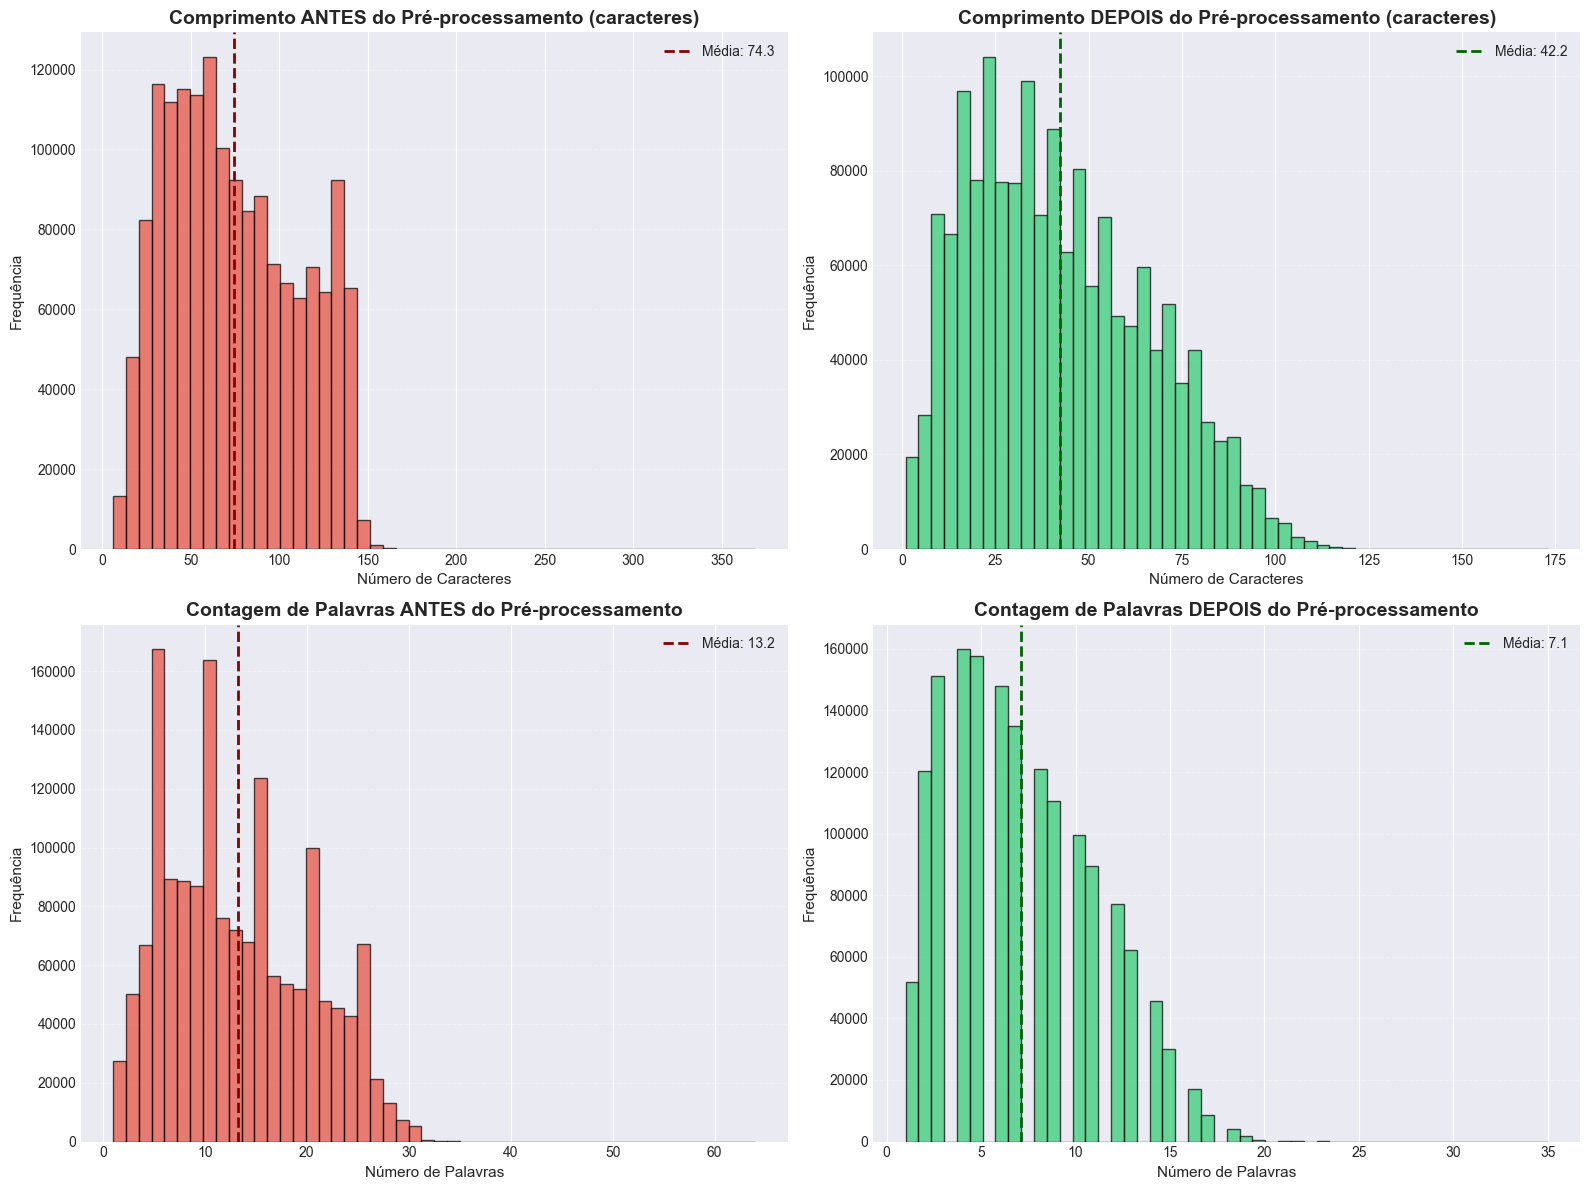


📊 RESUMO DA REDUÇÃO:
   - Caracteres: 43.2% de redução
   - Palavras: 46.2% de redução


In [15]:
# Criar visualizações comparativas
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histograma de comprimento (caracteres) - Antes
axes[0, 0].hist(df['text_length_original'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(df['text_length_original'].mean(), color='darkred', linestyle='--', linewidth=2,
                   label=f'Média: {df["text_length_original"].mean():.1f}')
axes[0, 0].set_title('Comprimento ANTES do Pré-processamento (caracteres)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Número de Caracteres', fontsize=11)
axes[0, 0].set_ylabel('Frequência', fontsize=11)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')

# 2. Histograma de comprimento (caracteres) - Depois
axes[0, 1].hist(df['text_length_clean'], bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(df['text_length_clean'].mean(), color='darkgreen', linestyle='--', linewidth=2,
                   label=f'Média: {df["text_length_clean"].mean():.1f}')
axes[0, 1].set_title('Comprimento DEPOIS do Pré-processamento (caracteres)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Número de Caracteres', fontsize=11)
axes[0, 1].set_ylabel('Frequência', fontsize=11)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')

# 3. Histograma de contagem de palavras - Antes
axes[1, 0].hist(df['word_count_original'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(df['word_count_original'].mean(), color='darkred', linestyle='--', linewidth=2,
                   label=f'Média: {df["word_count_original"].mean():.1f}')
axes[1, 0].set_title('Contagem de Palavras ANTES do Pré-processamento', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Número de Palavras', fontsize=11)
axes[1, 0].set_ylabel('Frequência', fontsize=11)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')

# 4. Histograma de contagem de palavras - Depois
axes[1, 1].hist(df['word_count_clean'], bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(df['word_count_clean'].mean(), color='darkgreen', linestyle='--', linewidth=2,
                   label=f'Média: {df["word_count_clean"].mean():.1f}')
axes[1, 1].set_title('Contagem de Palavras DEPOIS do Pré-processamento', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Número de Palavras', fontsize=11)
axes[1, 1].set_ylabel('Frequência', fontsize=11)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Calcular redução
reduction_chars = ((df['text_length_original'].mean() - df['text_length_clean'].mean()) /
                   df['text_length_original'].mean() * 100)
reduction_words = ((df['word_count_original'].mean() - df['word_count_clean'].mean()) /
                   df['word_count_original'].mean() * 100)

print(f"\n📊 RESUMO DA REDUÇÃO:")
print(f"   - Caracteres: {reduction_chars:.1f}% de redução")
print(f"   - Palavras: {reduction_words:.1f}% de redução")


## 9. Exemplos de Textos Após Pré-processamento


In [16]:
# Visualizar exemplos lado a lado: antes e depois
print("="*80)
print("COMPARAÇÃO DETALHADA: ANTES vs. DEPOIS")
print("="*80)

# Selecionar alguns exemplos representativos
sample_indices = df.head(5).index

for idx in sample_indices:
    original = df.loc[idx, 'text']
    cleaned = df.loc[idx, 'text_clean']
    label = df.loc[idx, 'label']
    sentiment = "NEGATIVO" if label == 0 else "POSITIVO"

    print(f"\n{'='*80}")
    print(f"Exemplo (Label: {label} - {sentiment})")
    print(f"{'='*80}")
    print(f"ANTES ({len(original)} caracteres, {len(original.split())} palavras):")
    print(f"  {original}")
    print(f"\nDEPOIS ({len(cleaned)} caracteres, {len(cleaned.split())} palavras):")
    print(f"  {cleaned}")
    print()


COMPARAÇÃO DETALHADA: ANTES vs. DEPOIS

Exemplo (Label: 0 - NEGATIVO)
ANTES (115 caracteres, 19 palavras):
  @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D

DEPOIS (50 caracteres, 9 palavras):
  awww thats bummer shoulda got david carr third day


Exemplo (Label: 0 - NEGATIVO)
ANTES (111 caracteres, 21 palavras):
  is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!

DEPOIS (74 caracteres, 12 palavras):
  upset cant update facebook texting might cry result school today also blah


Exemplo (Label: 0 - NEGATIVO)
ANTES (89 caracteres, 18 palavras):
  @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds

DEPOIS (47 caracteres, 9 palavras):
  dived many time ball managed save rest go bound


Exemplo (Label: 0 - NEGATIVO)
ANTES (47 caracteres, 10 palavras):
  my whole body feels itchy and like its on fire 

DEPOIS (31 caracteres

## 10. Salvar Dataset Pré-processado


In [17]:
# Preparar dataset final para salvar
# Manter apenas as colunas necessárias: text_clean e label
df_final = df[['text_clean', 'label']].copy()
df_final = df_final.rename(columns={'text_clean': 'text'})

# Salvar dataset pré-processado
output_path = '../data/sentiment140_preprocessed.csv'
print(f"Salvando dataset pré-processado em: {output_path}")

df_final.to_csv(output_path, index=False, encoding='utf-8')

print(f"✓ Dataset pré-processado salvo com sucesso!")
print(f"   - Shape: {df_final.shape}")
print(f"   - Colunas: {df_final.columns.tolist()}")
print(f"\nPrimeiras linhas do dataset salvo:")
df_final.head(10)


Salvando dataset pré-processado em: ../data/sentiment140_preprocessed.csv
✓ Dataset pré-processado salvo com sucesso!
   - Shape: (1591869, 2)
   - Colunas: ['text', 'label']

Primeiras linhas do dataset salvo:


,text,label
0,awww thats bummer shoulda got david carr third...,0
1,upset cant update facebook texting might cry r...,0
2,dived many time ball managed save rest go bound,0
3,whole body feel itchy like fire,0
4,behaving im mad cant see,0
5,whole crew,0
6,need hug,0
7,hey long time see yes rain bit bit lol im fine...,0
8,nope didnt,0
9,que muera,0


## 11. Resumo do Pré-processamento

### 📋 Passos Realizados:

1. ✅ **Limpeza de textos:**
   - Remoção de URLs (http/https/www)
   - Remoção de menções (@usuário)
   - Remoção de hashtags (#hashtag)

2. ✅ **Normalização:**
   - Conversão para minúsculas (lowercasing)
   - Remoção de pontuação
   - Remoção de números

3. ✅ **Tokenização:**
   - Divisão do texto em tokens (palavras)

4. ✅ **Remoção de stopwords:**
   - Remoção de palavras comuns em inglês que não agregam significado

5. ✅ **Lematização:**
   - Redução de palavras à sua forma base (ex: "running" → "run")

### 📊 Resultados:

- **Total de textos processados:** Ver célula acima
- **Textos removidos (vazios):** Ver célula acima
- **Redução média de caracteres e palavras:** Ver gráficos e estatísticas acima

### 💾 Arquivo Salvo:

- **Caminho:** `data/sentiment140_preprocessed.csv`
- **Formato:** CSV com colunas `text` (pré-processado) e `label`

### 🚀 Próximos Passos:

O dataset pré-processado está pronto para ser usado em:
- Modelos Baseline (TF-IDF + Logistic Regression)
- Modelos Transformer (BERT, RoBERTa, DistilBERT)
- Outras técnicas de análise de sentimentos
